In [1]:
import os, sys, json, pickle, time, copy, re, ast, warnings
from pathlib import Path
import numpy as np, pandas as pd

V8_NOTEBOOK = Path('/mnt/f415dcc8-27a5-4e66-8493-25f1d939974c/Thesis/Coding env/criticalReview/V8/V8.ipynb').resolve()
V8_DIR      = Path('/mnt/f415dcc8-27a5-4e66-8493-25f1d939974c/Thesis/Coding env/criticalReview/V8').resolve()               # folder holding V8's results_final.csv, cv_folds.csv, thresholds.csv, mcnemar.csv, tabular_baselines.csv
DATA_DIR    = Path('../../dataset').resolve()   # TCGA_InfoWithGrade.csv + weseq_processed_with_id_and_race_V2.csv
CGGA_CLIN   = Path('/mnt/f415dcc8-27a5-4e66-8493-25f1d939974c/Thesis/Coding env/dataset/weseq_286_Clinical.xlsx').resolve()
CGGA_MUT    = Path('/mnt/f415dcc8-27a5-4e66-8493-25f1d939974c/Thesis/Coding env/dataset/weseq_286_Mutation.csv').resolve()
WORK        = Path('v9_work').resolve()
CK = WORK/'ckpt'; TB = WORK/'tables'
for d in (WORK, CK, TB): d.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)      # V8's savefig calls now write here, never over your V8 files

def _p(n): return CK/f'{n}.pkl'
def ck_has(n): return _p(n).exists()
def ck_load(n):
    with open(_p(n), 'rb') as f: return pickle.load(f)
def ck_save(n, obj):
    tmp = _p(n).with_suffix('.tmp')
    with open(tmp, 'wb') as f: pickle.dump(obj, f)
    os.replace(tmp, _p(n))
def ckpt(name, fn, force=False):
    if ck_has(name) and not force:
        print(f'[ckpt] loaded  {name}'); return ck_load(name)
    t = time.time(); out = fn(); ck_save(name, out)
    print(f'[ckpt] saved   {name}  ({time.time()-t:.0f}s)'); return out
def ck_status():
    fs = sorted(CK.glob('*.pkl')); print(len(fs), 'checkpoints'); [print(' ', f.stem) for f in fs]

/home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/libpyg.so
  import torch_geometric.typing
/home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/torch_cluster/_version_cuda.so
  import torch_geomet

Using device: cuda
GPU: NVIDIA GeForce RTX 3050
TCGA: removed 2 rows with Age < 18 (839 → 837)
CGGA: removed 2 rows with Age < 18 (286 → 284)
TCGA: (837, 24)   Grade dist: {0: np.int64(485), 1: np.int64(352)}
CGGA: (284, 24)   Grade dist: {0: np.int64(182), 1: np.int64(102)}
Train(HPO)=535  Val(HPO)=134  TrainVal(CV)=669  Test=168
Train Grade dist: {0: np.int64(310), 1: np.int64(225)}
Test  Grade dist: {0: np.int64(97), 1: np.int64(71)}
Global scaler fit on train_val (n=669): mean=51.40, std=15.39
SCALE-FREE VERIFICATION — BA Graph Layers

───────────────────────────────────────────────────────
  Patient-Patient (seq BA)
───────────────────────────────────────────────────────
  gamma=OLS: 2.493  R2_PL=0.9588  R2_exp=0.8360  KS_p=0.9971

───────────────────────────────────────────────────────
  Gene-Gene (seq BA)
───────────────────────────────────────────────────────
  gamma=Hill: 1.973  R2_PL=0.8195  R2_exp=0.6652  KS_p=1.0000

  PP edges (undirected): 1335
  GG edges (undirected): 37

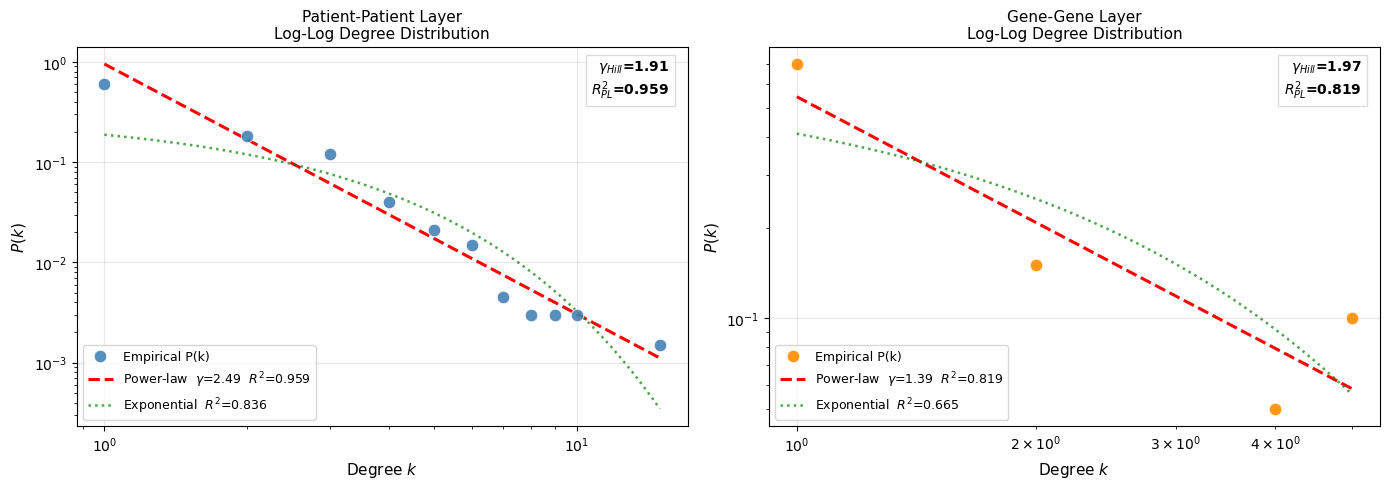

Saved: scalefree_degree_dist.png
Val  graph: 134 patients
Test graph: 168 patients
CGGA graph: 284 patients
Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']


In [2]:
nb8 = json.load(open(V8_NOTEBOOK))
SRC = [''.join(c['source']) for c in nb8['cells']]
for i in range(12):                      # V8 cells 0-11 only: imports, data, splits, graphs, models, helpers
    exec(compile(SRC[i].replace('../../dataset/', str(DATA_DIR) + '/'), f'V8_cell_{i}', 'exec'), globals())
assert len(train_val_df) + len(test_df) == 837 and len(cgga_df) == 284

pat = re.compile(r"\[([A-Za-z0-9]+)/([A-Za-z ]+)\] Best AUC=([\d.]+)\s+params=(\{.*?\})")
V8_PARAMS, V8_HPOVAL = {}, {}
for i in range(12, 16):
    for o in nb8['cells'][i].get('outputs', []):
        for m in pat.finditer(''.join(o.get('text', []))):
            V8_PARAMS[(m.group(1), m.group(2).strip())] = ast.literal_eval(m.group(4))
            V8_HPOVAL[(m.group(1), m.group(2).strip())] = float(m.group(3))
assert len(V8_PARAMS) == 28, len(V8_PARAMS)
MODEL_BY_NAME = {n: (C, k) for n, C, k in MODEL_REGISTRY}

In [3]:
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
res = pd.read_csv(V8_DIR/'results_final.csv'); cvf = pd.read_csv(V8_DIR/'cv_folds.csv'); thr = pd.read_csv(V8_DIR/'thresholds.csv')
TH = {(r.Model, r.Pipeline): r.Threshold for r in thr.itertuples()}
cv_mean = cvf.groupby(['Model', 'Pipeline'])['auc'].agg(cv_auc='mean', cv_sd='std')
rep = res.pivot_table(index=['Model', 'Pipeline'], columns='Dataset', values='AUC')
sel = cv_mean.join(rep).reset_index()
sel['hpo_val_auc'] = [V8_HPOVAL.get((m, p)) for m, p in zip(sel.Model, sel.Pipeline)]
sel = sel.sort_values('cv_auc', ascending=False).reset_index(drop=True)
sel.to_csv(TB/'selection_by_cv.csv', index=False)
print(sel.round(4).to_string(index=False))
print('\nCV-selected per model:'); print(sel.loc[sel.groupby('Model')['cv_auc'].idxmax()].round(4).to_string(index=False))
print('\nPost-hoc CGGA AUC range over 28 configs: %.4f - %.4f' % (sel['CGGA'].min(), sel['CGGA'].max()))
TOP = (sel.loc[0, 'Model'], sel.loc[0, 'Pipeline']); print('TOP by CV AUC:', TOP)

mc = pd.read_csv(V8_DIR/'mcnemar.csv')
mc['p_bonf'] = np.minimum(mc['p'] * len(mc), 1); mc['p_holm'] = multipletests(mc['p'], method='holm')[1]
mc.to_csv(TB/'mcnemar_corrected.csv', index=False)
print('\nMcNemar, n tests =', len(mc), '| threshold 0.05/n = %.4f' % (0.05 / len(mc)))
print(mc[mc.p < 0.05].round(4).to_string(index=False))

      Model     Pipeline  cv_auc  cv_sd   CGGA  TCGA Test  hpo_val_auc
FastHGTConv No Balancing  0.9276 0.0097 0.4920     0.9120       0.9437
FastHGTConv        SMOTE  0.9255 0.0170 0.6516     0.8936       0.9421
       VEGN No Balancing  0.9243 0.0067 0.5868     0.9127       0.9480
       SGNN        SMOTE  0.9239 0.0106 0.7749     0.9129       0.9423
       RGCN        SMOTE  0.9237 0.0144 0.7315     0.9191       0.9391
       RGCN No Balancing  0.9233 0.0141 0.7685     0.9151       0.9400
       RGCN        CTGAN  0.9227 0.0157 0.7853     0.9159       0.9359
      MOGAT No Balancing  0.9222 0.0115 0.7052     0.8994       0.9423
       RGCN          ROS  0.9211 0.0111 0.6981     0.9133       0.9439
FastHGTConv          ROS  0.9211 0.0045 0.4705     0.9103       0.9464
FastHGTConv        CTGAN  0.9209 0.0193 0.7144     0.9045       0.9448
       SGNN          ROS  0.9205 0.0169 0.7122     0.8876       0.9423
       VEGN        SMOTE  0.9191 0.0090 0.5321     0.9108       0.9462
Hetero

In [5]:
def summarize(df, name):
    d = {'n': len(df), 'Age mean±SD': f"{df['Age_at_diagnosis'].mean():.1f} ± {df['Age_at_diagnosis'].std():.1f}",
         'Female %': round(100 * df['Gender'].mean(), 1), 'Grade1 (GBM/WHO IV) %': round(100 * df['Grade'].mean(), 1)}
    for k, lab in enumerate(['White', 'Black', 'Asian', 'NativeAm']): d[f'Race {lab} %'] = round(100 * (df['Race'] == k).mean(), 1)
    for g in gene_columns: d[f'{g} %'] = round(100 * df[g].mean(), 1)
    return pd.Series(d, name=name)
cohort_tab = pd.concat([summarize(tcga_df, 'TCGA'), summarize(cgga_df, 'CGGA')], axis=1)
cohort_tab.to_csv(TB/'cohort_table.csv'); print(cohort_tab.to_string())

mut = pd.read_csv(CGGA_MUT, index_col='Gene_Name', low_memory=False)
clin = pd.read_excel(CGGA_CLIN).set_index('CGGA_ID')
flags_any = mut.loc[gene_columns].notna().astype(int).T
raw_ids = pd.read_csv(DATA_DIR/'weseq_processed_with_id_and_race_V2.csv').set_index('CGGA_ID')
com = raw_ids.index.intersection(flags_any.index)
print('\nflags: processed CSV vs "any reported variant" rule -> mismatched cells:',
      int((raw_ids.loc[com, gene_columns].values != flags_any.loc[com, gene_columns].values).sum()), 'of', len(com) * 20)
print('1p/19q available in CGGA clinical file:', clin['1p19q_codel_status'].notna().sum(), 'of', len(clin))

                              TCGA         CGGA
n                              837          284
Age mean±SD            51.0 ± 15.6  42.2 ± 12.1
Female %                      41.9         41.2
Grade1 (GBM/WHO IV) %         42.1         35.9
Race White %                  91.2          0.0
Race Black %                   7.0          0.0
Race Asian %                   1.7        100.0
Race NativeAm %                0.1          0.0
IDH1 %                        48.0         46.8
TP53 %                        41.5         45.4
ATRX %                        25.9         29.2
PTEN %                        16.8          6.7
EGFR %                        13.4          3.9
CIC %                         13.1         14.4
MUC16 %                       11.7          7.4
PIK3CA %                       8.7          6.0
NF1 %                          8.0          7.0
PIK3R1 %                       6.5          4.9
FUBP1 %                        5.4          4.2
RB1 %                          4.8      

In [7]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

def build_tab(df, sc):
    age = sc.transform(df[['Age_at_diagnosis']].values.astype(float)); race = np.zeros((len(df), 4))
    for i, rv in enumerate(df['Race'].values.astype(int)):
        if 0 <= rv < 4: race[i, rv] = 1
    return np.hstack([df[gene_columns].values.astype(float), df[['Gender']].values.astype(float), race, age]), df['Grade'].values
tab_sc = StandardScaler().fit(train_val_df[['Age_at_diagnosis']].values.astype(float))
X_trainval, y_trainval = build_tab(train_val_df, tab_sc); X_test, y_test = build_tab(test_df, tab_sc); X_cgga, y_cgga = build_tab(cgga_df, tab_sc)
FEAT = gene_columns + ['Gender', 'Race_White', 'Race_Black', 'Race_Asian', 'Race_NativeAm', 'Age_norm']
ALL = list(range(26)); IDH1 = FEAT.index('IDH1'); AGE = FEAT.index('Age_norm')
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n0_t, n1_t = (y_trainval == 0).sum(), (y_trainval == 1).sum()
BASELINES = {
 'XGBoost': (XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=n0_t / n1_t, n_jobs=2),
             {'n_estimators': [100, 300], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0]}, 1),
 'RandomForest': (RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
             {'n_estimators': [100, 300], 'max_depth': [None, 10], 'min_samples_leaf': [1, 3]}, -1),
 'SVM': (SVC(class_weight='balanced', random_state=42, probability=True), {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.001]}, -1),
 'MLP': (MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
             {'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)], 'alpha': [1e-4, 1e-3], 'learning_rate_init': [1e-3, 5e-4]}, -1)}
C_GRID = [0.01, 0.1, 1, 10]
def auc_scorer(est, X, y):
    return roc_auc_score(y, est.predict_proba(X)[:, 1])

def tab_run(name, est, cols, grid=None, n_jobs=-1):
    def _do():
        e = clone(est); cvs, bp = np.nan, {}
        if grid:
            gs = GridSearchCV(e, grid, cv=cv5, scoring=auc_scorer, n_jobs=n_jobs, error_score='raise').fit(X_trainval[:, cols], y_trainval)
            e, cvs, bp = gs.best_estimator_, gs.best_score_, gs.best_params_
        else: e.fit(X_trainval[:, cols], y_trainval)
        pt, pc = e.predict_proba(X_test[:, cols])[:, 1], e.predict_proba(X_cgga[:, cols])[:, 1]
        return dict(name=name, cv_auc=cvs, params=bp, p_test=pt, p_cgga=pc,
                    auc_test=roc_auc_score(y_test, pt), auc_cgga=roc_auc_score(y_cgga, pc))
    return ckpt(f'tab__{name}', _do)

TAB = {}
for n, (e, g, nj) in BASELINES.items(): TAB[n] = tab_run(n, e, ALL, g, nj)
TAB['LogReg'] = tab_run('LogReg', LogisticRegression(max_iter=2000, class_weight='balanced'), ALL, {'C': C_GRID})
TAB['ElasticNet'] = tab_run('ElasticNet', LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000, class_weight='balanced'),
                            ALL, {'C': C_GRID, 'l1_ratio': [0.2, 0.5, 0.8]})
TAB['IDH1-only LR'] = tab_run('IDH1-only LR', LogisticRegression(class_weight='balanced'), [IDH1])
TAB['IDH1+Age LR'] = tab_run('IDH1+Age LR', LogisticRegression(class_weight='balanced'), [IDH1, AGE])
tab_df = pd.DataFrame([{'Model': k, 'cv_auc': v['cv_auc'], 'TCGA_Test_AUC': v['auc_test'], 'CGGA_AUC': v['auc_cgga']} for k, v in TAB.items()])
tab_df.round(4).to_csv(TB/'tabular_extended.csv', index=False); print(tab_df.round(4).to_string(index=False))
assert tab_df.loc[tab_df.Model.isin(BASELINES), 'cv_auc'].notna().all(), 'a baseline CV score is NaN'
v8t = pd.read_csv(V8_DIR/'tabular_baselines.csv'); v8t = v8t[v8t.Model.str.startswith('Baseline/')]
print('\nV8 tabular_baselines.csv for comparison:'); print(v8t[['Model', 'Dataset', 'AUC']].to_string(index=False))

[ckpt] saved   tab__XGBoost  (3s)


/home/nafim/anaconda3/envs/glioma/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/nafim/anaconda3/envs/glioma/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/nafim/anaconda3/envs/glioma/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using 

[ckpt] saved   tab__RandomForest  (8s)
[ckpt] saved   tab__SVM  (0s)
[ckpt] saved   tab__MLP  (2s)
[ckpt] saved   tab__LogReg  (0s)
[ckpt] saved   tab__ElasticNet  (0s)
[ckpt] saved   tab__IDH1-only LR  (0s)
[ckpt] saved   tab__IDH1+Age LR  (0s)
       Model  cv_auc  TCGA_Test_AUC  CGGA_AUC
     XGBoost  0.9227         0.9249    0.7444
RandomForest  0.9176         0.9291    0.7960
         SVM  0.9117         0.9162    0.7360
         MLP  0.9077         0.9307    0.7887
      LogReg  0.9162         0.9249    0.7786
  ElasticNet  0.9163         0.9251    0.7758
IDH1-only LR     NaN         0.8687    0.6971
 IDH1+Age LR     NaN         0.9165    0.7689

V8 tabular_baselines.csv for comparison:
                Model   Dataset    AUC
     Baseline/XGBoost TCGA Test 0.9286
     Baseline/XGBoost      CGGA 0.7800
Baseline/RandomForest TCGA Test 0.9291
Baseline/RandomForest      CGGA 0.7960
         Baseline/SVM TCGA Test 0.9162
         Baseline/SVM      CGGA 0.7360
         Baseline/MLP TCG

In [8]:
final_scaler = StandardScaler().fit(train_val_df[['Age_at_diagnosis']].values.astype(float))
AUG_FN = {'No Balancing': None, 'SMOTE': apply_smote, 'ROS': apply_ros, 'CTGAN': apply_ctgan}
def get_aug(pipe):
    if AUG_FN[pipe] is None: return train_val_df
    def _do():
        set_seed(42); return AUG_FN[pipe](train_val_df.copy())
    return ckpt(f'aug__{pipe}', _do)

def build_model(MCls, bp, fkw, init_graph, state=None):
    kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2, 'num_heads': bp['num_heads'], 'dropout': bp['dropout']}; kw.update(fkw)
    m = MCls(**kw).to(device)
    try:
        with torch.no_grad(): _ = m(init_graph)
    except Exception: pass
    if state is not None: m.load_state_dict(state)
    return m

def repro(mname, pipe):
    def _do():
        MCls, fkw = MODEL_BY_NAME[mname]; bp = V8_PARAMS[(mname, pipe)]; th = TH[(mname, pipe)]
        g = to_dev(construct_scalefree_bipartite_heterograph(get_aug(pipe), scaler=final_scaler))
        _, state, _ = train_and_evaluate(g, val_graph, bp, MCls, fkw, seed=42, loss_fn=make_criterion(g, verbose=False))
        mdl = build_model(MCls, bp, fkw, g, state)
        out = {'Model': mname, 'Pipeline': pipe, 'th': th}
        for ds, gr in [('TCGA Test', test_graph), ('CGGA', cgga_graph)]:
            _, p, l = evaluate_model(mdl, gr, th); out[ds] = {'probs': p, 'labels': l, 'auc': roc_auc_score(l, p)}
        return out
    return ckpt(f'repro__{mname}__{pipe}', _do)

REPRO_LIST = list(dict.fromkeys([TOP, ('MOGAT', 'CTGAN'), ('RGCN', 'CTGAN')]))
REP = {k: repro(*k) for k in REPRO_LIST}
chk = []
for (m, p), r in REP.items():
    v8 = res[(res.Model == m) & (res.Pipeline == p)].set_index('Dataset')['AUC']
    chk.append({'Model': m, 'Pipeline': p, 'TCGA V8': v8['TCGA Test'], 'TCGA now': round(r['TCGA Test']['auc'], 4),
                'CGGA V8': v8['CGGA'], 'CGGA now': round(r['CGGA']['auc'], 4)})
chk = pd.DataFrame(chk); chk.to_csv(TB/'repro_check.csv', index=False); print(chk.to_string(index=False))
print('CTGAN configs may differ slightly (synthetic sample is regenerated). If so, report the NEW numbers.')

[ckpt] saved   repro__FastHGTConv__No Balancing  (6s)


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 697.32it/s]


[ckpt] saved   aug__CTGAN  (37s)
[ckpt] saved   repro__MOGAT__CTGAN  (39s)
[ckpt] loaded  aug__CTGAN
[ckpt] saved   repro__RGCN__CTGAN  (4s)
      Model     Pipeline  TCGA V8  TCGA now  CGGA V8  CGGA now
FastHGTConv No Balancing   0.9120    0.9120   0.4920    0.4920
      MOGAT        CTGAN   0.9203    0.9203   0.7306    0.7306
       RGCN        CTGAN   0.9159    0.9159   0.7853    0.7853
CTGAN configs may differ slightly (synthetic sample is regenerated). If so, report the NEW numbers.


In [9]:
import torch.nn as nn
class HomoGCN(nn.Module):
    """Single node type (patients). Mutation vector built from gene->patient edges; message passing over patient-patient edges only."""
    def __init__(self, hidden_dim=64, out_dim=2, num_heads=1, dropout=0.3):
        super().__init__()
        self.c1, self.c2, self.out, self.dp = GCNConv(26, hidden_dim), GCNConv(hidden_dim, hidden_dim), nn.Linear(hidden_dim, out_dim), dropout
    def forward(self, g):
        x = g['Patient'].x; n = x.size(0); ei = g[('Gene', 'mutates', 'Patient')].edge_index
        M = torch.zeros(n, 20, device=x.device); M[ei[1], ei[0]] = 1.0
        pp = g[('Patient', 'cooccurs', 'Patient')].edge_index
        h = F.dropout(F.relu(self.c1(torch.cat([M, x], 1), pp)), self.dp, self.training)
        return self.out(F.relu(self.c2(h, pp)))

def run_homog():
    global MODEL_REGISTRY
    saved = MODEL_REGISTRY; n0 = len(all_results); tag = 'No Balancing [homog]'
    try:
        MODEL_REGISTRY = [('HomoGCN', HomoGCN, {})]
        sc = StandardScaler().fit(train_df[['Age_at_diagnosis']].values.astype(float))
        g = to_dev(construct_scalefree_bipartite_heterograph(train_df, scaler=sc))
        run_pipeline(tag, train_graph_hpo=g, augment_fn=None, graph_fn=construct_scalefree_bipartite_heterograph)
    finally: MODEL_REGISTRY = saved
    return {'results': all_results[n0:], 'params': all_params[('HomoGCN', tag)], 'th': all_thresholds[('HomoGCN', tag)]}
H = ckpt('homog__HomoGCN', run_homog)
hv = pd.DataFrame([{k: r[k] for k in ('Model', 'Pipeline', 'Dataset', 'auc')} for r in H['results']]).round(4)
hv.to_csv(TB/'homogeneous_gnn.csv', index=False); print(hv.to_string(index=False)); ck_status()


PIPELINE: No Balancing [homog]

  -- HomoGCN --
    Class weights: Grade-0=0.8629  Grade-1=1.1889  (n0=310, n1=225)


  0%|          | 0/30 [00:00<?, ?it/s]

  [HomoGCN/No Balancing [homog]] Best AUC=0.8665  params={'hidden_dim': 32, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.007785697364329748, 'weight_decay': 0.0003648188653456667}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8455 R1=0.789 R0=0.805 F1=0.7692 th=0.49
    Fold 2/5 | AUC=0.8075 R1=0.750 R0=0.769 F1=0.7241 th=0.53
    Fold 3/5 | AUC=0.8363 R1=0.768 R0=0.885 F1=0.7963 th=0.50
    Fold 4/5 | AUC=0.8267 R1=0.786 R0=0.731 F1=0.7273 th=0.57
    Fold 5/5 | AUC=0.8613 R1=0.786 R0=0.831 F1=0.7788 th=0.50
    auc         : 0.8355 +/- 0.0202
    accuracy    : 0.7923 +/- 0.0346
    precision   : 0.7452 +/- 0.0594
    recall      : 0.7758 +/- 0.0167
    recall_0    : 0.8042 +/- 0.0588
    f1          : 0.7591 +/- 0.0320
    threshold   : 0.5150 +/- 0.0341
    Class weights: Grade-0=0.8621  Grade-1=1.1904  (n0=388, n1=281)
  Final threshold (mean of CV folds) = 0.515
  TCGA-Test  AUC=0.8483 R1=0.761 R0=0.753 F1=0.7248
  CGGA       AUC=0.6390 R1=1.000 R0=0.000 F1=0.5285


In [10]:
def _mid(x):
    J = np.argsort(x); Z = x[J]; N = len(x); T = np.zeros(N); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]: j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1; i = j
    o = np.empty(N); o[J] = T; return o
def delong_2(y, p1, p2):
    y = np.asarray(y); pos = y == 1; m, n = pos.sum(), (~pos).sum(); P = np.vstack([p1, p2])
    tx, ty, tz = np.empty((2, m)), np.empty((2, n)), np.empty((2, m + n))
    for r in range(2):
        px, py = P[r, pos], P[r, ~pos]; tx[r], ty[r], tz[r] = _mid(px), _mid(py), _mid(np.concatenate([px, py]))
    a = tz[:, :m].sum(1) / m / n - (m + 1) / 2 / n
    S = np.cov((tz[:, :m] - tx) / n) / m + np.cov(1 - (tz[:, m:] - ty) / m) / n
    d = a[0] - a[1]; z = d / np.sqrt(S[0, 0] + S[1, 1] - 2 * S[0, 1]); return a[0], a[1], d, z, 2 * norm.sf(abs(z))
def boot_ci(y, p1, p2, n=5000, seed=42):
    rng = np.random.default_rng(seed); y = np.asarray(y); d = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(set(y[i])) == 2: d.append(roc_auc_score(y[i], p1[i]) - roc_auc_score(y[i], p2[i]))
    return np.percentile(d, [2.5, 97.5])
rows = []
for (m, p), r in REP.items():
    for ds, key in [('TCGA Test', 'p_test'), ('CGGA', 'p_cgga')]:
        pg, yg = r[ds]['probs'], r[ds]['labels']
        for tn_ in ['XGBoost', 'RandomForest', 'SVM', 'MLP', 'LogReg', 'ElasticNet']:
            a1, a2, d, z, pv = delong_2(yg, pg, TAB[tn_][key]); lo, hi = boot_ci(yg, pg, TAB[tn_][key])
            rows.append({'GNN': f'{m}+{p}', 'Dataset': ds, 'vs': tn_, 'AUC_gnn': round(a1, 4), 'AUC_tab': round(a2, 4),
                         'dAUC': round(d, 4), 'CI_lo': round(lo, 4), 'CI_hi': round(hi, 4), 'Z': round(z, 3), 'p': round(pv, 4)})
dl = pd.DataFrame(rows); dl.to_csv(TB/'delong_gnn_vs_tabular.csv', index=False); print(dl.to_string(index=False))

                     GNN   Dataset           vs  AUC_gnn  AUC_tab    dAUC   CI_lo   CI_hi      Z      p
FastHGTConv+No Balancing TCGA Test      XGBoost   0.9120   0.9249 -0.0129 -0.0415  0.0117 -0.933 0.3508
FastHGTConv+No Balancing TCGA Test RandomForest   0.9120   0.9291 -0.0171 -0.0452  0.0051 -1.337 0.1811
FastHGTConv+No Balancing TCGA Test          SVM   0.9120   0.9162 -0.0042 -0.0344  0.0229 -0.293 0.7695
FastHGTConv+No Balancing TCGA Test          MLP   0.9120   0.9307 -0.0187 -0.0514  0.0107 -1.196 0.2318
FastHGTConv+No Balancing TCGA Test       LogReg   0.9120   0.9249 -0.0129 -0.0452  0.0152 -0.855 0.3926
FastHGTConv+No Balancing TCGA Test   ElasticNet   0.9120   0.9251 -0.0131 -0.0451  0.0149 -0.872 0.3835
FastHGTConv+No Balancing      CGGA      XGBoost   0.4920   0.7444 -0.2525 -0.3255 -0.1793 -6.859 0.0000
FastHGTConv+No Balancing      CGGA RandomForest   0.4920   0.7960 -0.3041 -0.3797 -0.2271 -7.936 0.0000
FastHGTConv+No Balancing      CGGA          SVM   0.4920   0.736

In [11]:
ids = pd.read_csv(DATA_DIR/'weseq_processed_with_id_and_race_V2.csv'); ids = ids[ids['Age_at_diagnosis'] >= 18].reset_index(drop=True)
who = ids.merge(pd.read_excel(CGGA_CLIN)[['CGGA_ID', 'Grade']].rename(columns={'Grade': 'WHO'}), on='CGGA_ID', how='left', validate='one_to_one')['WHO'] \
        .map({'WHO II': 2, 'WHO III': 3, 'WHO IV': 4}).values
assert len(who) == 284 and not pd.isna(who).any() and ((who == 4).astype(int) == cgga_df['Grade'].values).all()
who = who.astype(int)
def sens(p):
    return {nm: round(roc_auc_score((who[k] == pos).astype(int), p[k]), 4)
            for nm, k, pos in [('II vs IV', who != 3, 4), ('III vs IV', who != 2, 4), ('II vs III', who != 4, 3)]}
rows = [{'Model': f'{m}+{p}', 'binary II/III vs IV': round(r['CGGA']['auc'], 4), **sens(r['CGGA']['probs'])} for (m, p), r in REP.items()]
rows += [{'Model': n, 'binary II/III vs IV': round(TAB[n]['auc_cgga'], 4), **sens(TAB[n]['p_cgga'])}
         for n in ['RandomForest', 'MLP', 'XGBoost', 'SVM', 'LogReg', 'ElasticNet']]
pd.DataFrame(rows).to_csv(TB/'cgga_label_sensitivity.csv', index=False); print(pd.DataFrame(rows).to_string(index=False))

                   Model  binary II/III vs IV  II vs IV  III vs IV  II vs III
FastHGTConv+No Balancing               0.4920    0.4803     0.5042     0.4747
             MOGAT+CTGAN               0.7306    0.7521     0.7082     0.5654
              RGCN+CTGAN               0.7853    0.8150     0.7542     0.5944
            RandomForest               0.7960    0.8233     0.7676     0.5845
                     MLP               0.7887    0.8119     0.7644     0.5705
                 XGBoost               0.7444    0.7800     0.7072     0.5705
                     SVM               0.7360    0.7567     0.7143     0.5480
                  LogReg               0.7786    0.8038     0.7523     0.5828
              ElasticNet               0.7758    0.8002     0.7503     0.5830
